# Benedictus Irvanda Nugroho
## Mini Assignment

In [2496]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

## 1. Import Data

In [2497]:
df = pd.read_csv(r'C:\Users\Irvan N\Documents\IRVAN\Work\Dibimbing\Python\Assignment\ebay_womens_perfume.csv')
df.head(5)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States"
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong"
2,PRADA,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.0,More than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States"
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong"
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States"


## 2. Data Exploration

In [2498]:
# melihat informasi tipe data dan null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               998 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          869 non-null    float64
 6   availableText      992 non-null    object 
 7   sold               984 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [2499]:
# deskriptif analisis
df.describe()

,price,available,sold
count,1000.000000,869.000000,984.000000
mean,39.892980,21.426928,497.321138
std,29.072186,51.476703,1372.510561
min,1.990000,2.000000,1.000000
25%,20.700000,6.000000,15.000000
50%,32.990000,10.000000,52.000000
75%,49.990000,10.000000,263.750000
max,299.990000,557.000000,17854.000000


In [2500]:
df.shape

(1000, 10)

In [2501]:
# melihat jumlah null values per kolom
df.isna().sum()

brand                  1
title                  0
type                   2
price                  0
priceWithCurrency      0
available            131
availableText          8
sold                  16
lastUpdated           73
itemLocation           0
dtype: int64

In [2502]:
df.duplicated().sum()

np.int64(1)

In [2503]:
# menampilkan data duplikat
df[df.duplicated(keep = False)]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
344,FLOWER,12 Piece Woman’s Perfume Lot: Assorted scents ...,Perfume,48.0,US $48.00,4.0,4 available / 1 sold,1.0,NaN,"Webster, Florida, United States"
662,FLOWER,12 Piece Woman’s Perfume Lot: Assorted scents ...,Perfume,48.0,US $48.00,4.0,4 available / 1 sold,1.0,NaN,"Webster, Florida, United States"


In [2504]:
(df.isnull().sum() / len(df)) * 100

brand                 0.1
title                 0.0
type                  0.2
price                 0.0
priceWithCurrency     0.0
available            13.1
availableText         0.8
sold                  1.6
lastUpdated           7.3
itemLocation          0.0
dtype: float64

In [2505]:
df['brand'].value_counts().head(20)

brand
Lancôme               37
Versace               33
Dolce&Gabbana         30
Jo Malone             29
Carolina Herrera      27
Victoria's Secret     26
Yves Saint Laurent    25
Ariana Grande         25
Burberry              21
Parfums de Marly      19
Thierry Mugler        18
Calvin Klein          17
Gucci                 16
Coach                 15
AS SHOWN              15
Marc Jacobs           14
Juicy Couture         13
Dossier               13
Dolce & Gabbana       13
Givenchy              13
Name: count, dtype: int64

In [2506]:
import matplotlib.pyplot as plt
import seaborn as sns

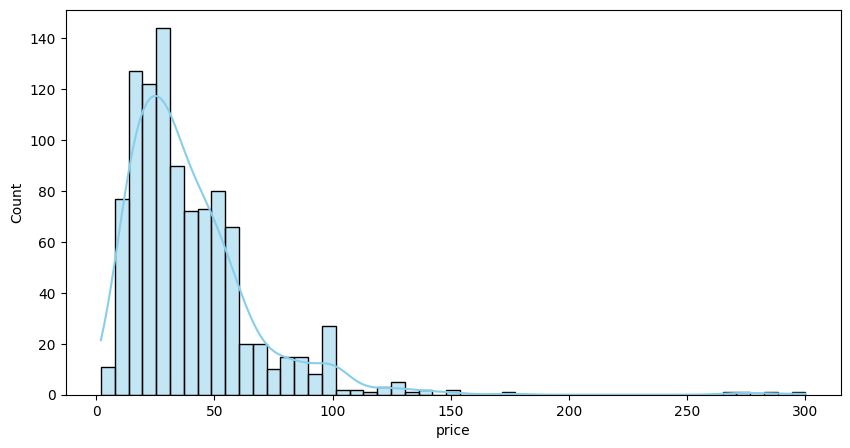

In [2507]:
# memeriksa distribusi normal (left skewed)
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.show()

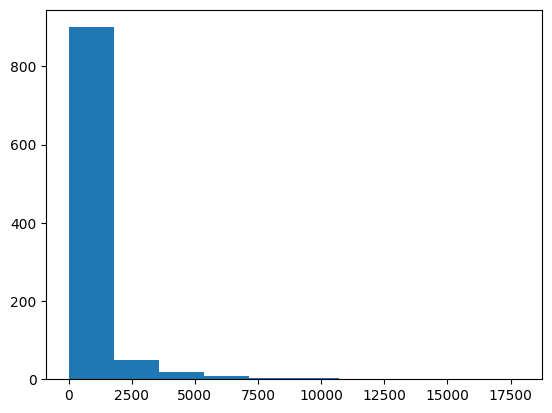

In [2508]:
plt.hist(df['sold'], bins=10)
plt.show()

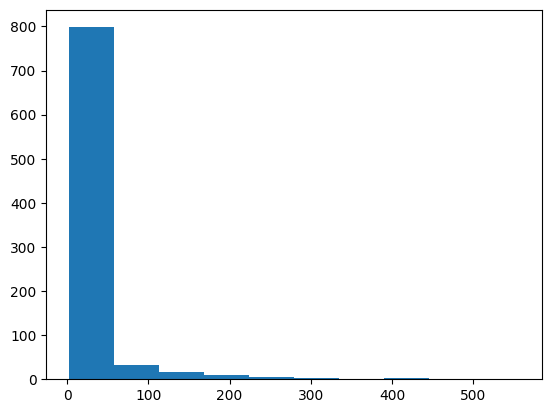

In [2509]:
plt.hist(df['available'], bins=10)
plt.show()

In [2510]:
df_clean = df.copy()
df_clean['brand'] = df_clean['brand'].str.strip().str.title()
df_clean

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,US $43.99/ea,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50 PDT","Thomasville, Alabama, United States"
1,As Shown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong"
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,10.0,More than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25 PDT","Orange, New Jersey, United States"
3,As Show,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong"
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States"
...,...,...,...,...,...,...,...,...,...,...
995,Avon,Avon Far Away Infinity Eau de Parfum 1.7 fl. o...,Eau de Parfum,13.89,US $13.89,10.0,More than 10 available / 157 sold,157.0,"May 16, 2024 22:35:29 PDT","West Palm Beach, Florida, United States"
996,Mancera,Roses Greedy by Mancera perfume for unisex EDP...,Eau de Parfum,57.85,US $57.85/ea,33.0,33 available / 58 sold,58.0,"May 24, 2024 08:03:11 PDT","Dallas, Texas, United States"
997,Unbranded,"Sweet Tooth Eau de Parfum, Perfume for Women, ...",1,30.96,US $30.96,2.0,2 available / 3 sold,3.0,"May 17, 2024 23:16:41 PDT","New York, New York, United States"
998,Juliette Has A Gun,MMMM BY Juliette Has A Gun perfume for her EDP...,Eau de Perfume,53.99,US $53.99/ea,3.0,3 available / 117 sold,117.0,"May 13, 2024 22:19:34 PDT","Dallas, Texas, United States"


In [2511]:
df_clean['type'].unique()

array(['Eau de Parfum', 'Eau de Toilette', 'Eau De Parfum', 'Spray',
       '~ BODY FIRM ADVANCED BODY REPAIR TREATMENT ~', 'Parfum',
       'Fragrance Mist', 'Deodorant Stick', 'Gift Sets', 'Eau de Perfume',
       'Eau de Cologne', '3 Pc', 'Eau de Parfum, Eau De Parfume',
       'Body Spray', 'Extrait de Parfum', 'Mist',
       'Eau de Toilette, Spray', 'Perfume', '/', 'Perfume, Eau de Parfum',
       'Fragrances', 'Eau De Cologne', 'Hair Perfume',
       'Eau de Parfum, Spray', 'Cream', 'Eau De Parfum 2 Pcs Set', 'EDT',
       "L'Eau de Parfum", 'Eau de Parfume', "L'eau de Parfum",
       'SKIN_MOISTURIZER', 'EDP and Parfum', 'Fine Fragrance Mist',
       'Lotion', 'Does not apply', 'Scented Oils', 'Shimmer', 'EDP',
       'Eau De Toilette', 'Perfume Fragrance Mist', 'Perfume Oil',
       'Parfum, Lotion, Gloss and Blush', nan, 'Bath Oil',
       'Elixir De Parfum', 'Body Mist', 'ASST', 'BEAUTY',
       'Extract Parfum', 'Does Not Apply', 'Shimmering Body Oil',
       'Body Powder',

## 3. Data Cleaning

In [2512]:
df_clean['type'] = df_clean['type'].str.lower().str.strip()
(df_clean['type'].nunique())

65

In [2513]:
def categorize_type_refined(text):
    text = str(text).lower()
    
    if 'extrait' in text or 'elixir' in text:
        return 'Extrait de Parfum'
    
    # Kelompok Eau de Parfum (EDP) & Parfum
    edp_keywords = ['eau de parfum', 'edp', 'parfum', 'perfume', 'parfume', 'elixir', 'fragrance', 'spray']
    if any(kw in text for kw in edp_keywords):
        return 'Eau de Parfum'
    
    # Kelompok Eau de Toilette (EDT)
    edt_keywords = ['eau de toilette', 'edt', 'toilette']
    if any(kw in text for kw in edt_keywords):
        return 'Eau de Toilette'
    
    # Kelompok Cologne
    cologne_keywords = ['cologne', 'edc']
    if any(kw in text for kw in cologne_keywords):
        return 'Cologne'
    
    # Kelompok Body Mist
    mist_keywords = ['mist', 'body spray', 'fragrance mist', 'shimmer']
    if any(kw in text for kw in mist_keywords):
        return 'Body Mist'
    
    # Kelompok Gift Set
    set_keywords = ['set', 'pc', 'gift', 'asst']
    if any(kw in text for kw in set_keywords):
        return 'Gift Set'

    body_care_keywords = ['lotion', 'cream', 'moisturizer', 'deodorant', 'powder', 'bath oil', 'skin_moisturizer']
    if any(kw in text for kw in body_care_keywords):
        return 'Body Care'
    
    # Kelompok Unknown / Data Sampah
    unknown_keywords = ['does not apply', '/', '1', 'nan', 'beauty']
    if any(kw in text for kw in unknown_keywords) or text.isdigit():
        return 'Unknown'
    
    return 'Others'

# Terapkan ulang
df_clean['type'] = df_clean['type'].apply(categorize_type_refined)

In [2514]:
# type setelah dicleaning
df_clean['type'].unique()

array(['Eau de Parfum', 'Eau de Toilette', 'Others', 'Body Care',
       'Gift Set', 'Cologne', 'Extrait de Parfum', 'Body Mist', 'Unknown'],
      dtype=object)

In [2515]:
df_clean['type'].value_counts()

type
Eau de Parfum        729
Eau de Toilette      192
Cologne               41
Body Care             13
Gift Set               7
Unknown                7
Extrait de Parfum      4
Body Mist              4
Others                 3
Name: count, dtype: int64

In [2516]:
# cek type kategori yang unknown
df_clean[df_clean['type'] == "Unknown"]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
99,Unbranded,Yara by Lattafa Perfumes | Eau De Parfum-100ml...,Unknown,15.89,US $15.89,10.0,More than 10 available / 434 sold,434.0,"May 24, 2024 06:56:49 PDT","shanghai, China"
377,Kate Spade New York,In Full Bloom Blush by Kate Spade for Women - ...,Unknown,14.40,US $14.40,5.0,5 available / 73 sold,73.0,"May 22, 2024 21:21:54 PDT","Old Bethpage, New York, United States"
463,As Show,Carmina By Creed EDP 75ml 2.5 oz Spray For Wom...,Unknown,128.88,US $128.88,10.0,10 available / 21 sold,21.0,"May 24, 2024 00:32:16 PDT","New Jersey, United States, Hong Kong"
565,Al-Rehab,Soft - Al-Rehab Eau De Natural Perfume Spray -...,Unknown,9.25,US $9.25,10.0,More than 10 available / 30 sold,30.0,"Apr 23, 2024 22:21:10 PDT","Princeton, New Jersey, United States"
574,Cacharel,Noa by Cacharel for Women Eau de Toilette Spra...,Unknown,20.00,US $20.00/ea,10.0,More than 10 available / 79 sold,79.0,"Apr 28, 2024 19:08:51 PDT","New York, New York, United States"
856,NaN,Bright Crystal de Versace Eau de Toilette 3.0 ...,Unknown,29.99,US $29.99,NaN,2 disponibles / 3 vendidos,NaN,23 may 2024 02:42:14 EST,"Hamtramck, Michigan, Estados Unidos"
997,Unbranded,"Sweet Tooth Eau de Parfum, Perfume for Women, ...",Unknown,30.96,US $30.96,2.0,2 available / 3 sold,3.0,"May 17, 2024 23:16:41 PDT","New York, New York, United States"


In [2517]:
# mengganti type dengan mencocokan dengan title nya
df_clean.at[99, 'type'] = "Eau de Parfum"
df_clean.at[377, 'type'] = "Eau de Parfum"
df_clean.at[463, 'type'] = "Eau de Parfum"
df_clean.at[565, 'type'] = "Perfume Spray"
df_clean.at[574, 'type'] = "Eau de Toilette"
df_clean.at[856, 'type'] = "Eau de Toilette"
df_clean.at[997, 'type'] = "Eau de Parfum"

In [2518]:
# cek type kategori yang others
df_clean[df_clean['type'] == "Others"]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
21,~ Crepe Erase ~,CREPE ERASE-BODY FIRM ADVANCED BODY REPAIR TRE...,Others,29.99,US $29.99,10.0,More than 10 available / 1 sold,1.0,NaN,"Melrose Park, Illinois, United States"
382,Spiritual Sky,(2-Pack) Patchouly Musk Scented Oil - Spiritua...,Others,12.99,US $12.99/ea,10.0,More than 10 available / 49 sold,49.0,"May 24, 2024 04:28:37 PDT","Miami, Florida, United States"
942,Pink Sugar,Premium Fragrance Body Oil PINK SUGAR for Wome...,Others,33.50,US $33.50,10.0,More than 10 available / 11 sold,11.0,"Mar 19, 2024 15:56:37 PDT","New York, New York, United States"


In [2519]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               1000 non-null   object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          869 non-null    float64
 6   availableText      992 non-null    object 
 7   sold               984 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


### Menangani Data Duplikat

In [2520]:
df_dup = df_clean.copy()

In [2521]:
df_dup[df_dup.duplicated(keep=False)]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
344,Flower,12 Piece Woman’s Perfume Lot: Assorted scents ...,Eau de Parfum,48.0,US $48.00,4.0,4 available / 1 sold,1.0,NaN,"Webster, Florida, United States"
662,Flower,12 Piece Woman’s Perfume Lot: Assorted scents ...,Eau de Parfum,48.0,US $48.00,4.0,4 available / 1 sold,1.0,NaN,"Webster, Florida, United States"


In [2522]:
# drop data duplikat
df_dup = df_dup.drop_duplicates(keep='first')

In [2523]:
df_dup.duplicated().sum()

np.int64(0)

In [2524]:
df_dup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              998 non-null    object 
 1   title              999 non-null    object 
 2   type               999 non-null    object 
 3   price              999 non-null    float64
 4   priceWithCurrency  999 non-null    object 
 5   available          868 non-null    float64
 6   availableText      991 non-null    object 
 7   sold               983 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       999 non-null    object 
dtypes: float64(3), object(7)
memory usage: 85.9+ KB


### Cleaning Kolom Brand

In [2525]:
df_clean_2 = df_dup.copy()

In [2526]:
# menampilkan unique
df_clean_2['brand'].unique()

array(['Carolina Herrera', 'As Shown', 'Prada', 'As Show', 'Khadlaj',
       'Viktor & Rolf', 'Versace', 'Lattafa', 'Yves Saint Laurent',
       'Gucci', 'Coach', 'Guerlain', 'Philosophy', 'Marc Jacobs',
       'Dolce & Gabbana', 'Qrc', '~ Crepe Erase ~', 'Unbranded', 'Ysl',
       'Parfums De Marly', 'Dolce&Gabbana', 'Ex Nihilo',
       'Juliette Has A Gun', 'Davidoff', 'Giorgi^O Armani', 'Roja',
       'Ariana Grande', 'Sol De Janeiro', 'Kilian', 'Donna Karan',
       'Narciso Rodriguez', 'Giorgio² Armani', 'Kenzo', 'Burberry',
       'Thierry Mugler', 'Juicy Couture', 'Maison Margiela', 'Jo Malone',
       'Elizabeth Arden', 'Urban Outfitters', 'Dossier',
       'Maison Alhambra', 'Alt Fragrances', 'Estée Lauder',
       "Victoria'S Secret", 'Kim Kardashian', 'Gap', 'Cacharel',
       'Jessica Mcclintock', 'As  Shown', 'Clinique', 'Valentino',
       'Giorgio Armani', 'Jimmy Choo', 'Calvin Klein', 'Alfred Sung',
       'Gloria Vanderbilt', 'Parfums', 'Ouai', 'Lancôme',
       'Ellis

In [2527]:
# menampilkan unique
df_clean_2['brand'].nunique()

235

### Mapping untuk memperbaiki variasi & typo

In [2528]:
# mapping / kategorisasi brand
brand_mapping = {
    'Ysl': 'Yves Saint Laurent',
    'Tf': 'Tom Ford',
    'Jlo': 'Jennifer Lopez',
    'J Lo': 'Jennifer Lopez',
    'Dolce&Gabbana': 'Dolce & Gabbana',
    'Dolce & Gabbana': 'Dolce & Gabbana',
    'Dolce Gabbana': 'Dolce & Gabbana',
    'Giorgio² Armani': 'Giorgio Armani',
    'Giorgio Arm.Ani': 'Giorgio Armani',
    'Giorgi^O Armani': 'Giorgio Armani',
    'Gianni Versace': 'Versace',
    'Lancome': 'Lancôme',
    'Estee Lauder': 'Estée Lauder',
    'Victoria\'S Secret': 'Victoria\'s Secret',
    'M·A·C': 'MAC'
}

junk_list = [
    'As Shown', 'As Show', 'As  Shown', 'As Picture Show', 
    'As Showed', 'See Photo', 'Unbranded', 'Generic', 
    'Multiple Brands', 'Perfume', 'Parfum', 'Asst', 'Assorted', '1'
]

In [2529]:
# Standardisasi format awal (title case dan strip)
df_clean_2['brand'] = df_clean_2['brand'].str.strip().str.title()

In [2530]:
# ganti semua junk list menjadi unknown
df_clean_2['brand'] = df_clean_2['brand'].replace(junk_list, 'Unknown')

In [2531]:
# terapkan mapping untuk typo/variasi
df_clean_2['brand'] = df_clean_2['brand'].replace(brand_mapping)

In [2532]:
# melihat baris yang brand cleaned nya masih unknown, untuk cek title parfum nya
df_clean_2[df_clean_2['brand'] == 'Unknown'].head(5)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,US $79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48 PDT","New Jersey, Hong Kong"
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,US $59.99/ea,10.0,More than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05 PDT","USA, New Jersey, Hong Kong"
6,Unknown,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,58.99,US $58.99,NaN,Out of Stock / 18 sold,18.0,"May 24, 2024 00:15:13 PDT","Astoria, New York, United States"
18,Unknown,PRADA Paradoxe By Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,US $59.99,NaN,Last One / 43 sold,43.0,"May 23, 2024 01:10:19 PDT","New York, New York, United States"
22,Unknown,Lattafa YARA by Lattafa 3.4 Oz (100 ml) EDP Ea...,Eau de Parfum,16.27,US $16.27/ea,300.0,300 available / 38 sold,38.0,"May 24, 2024 08:20:15 PDT","shanghai, China"


### Didapatkan bahwa brand yang unknown ada 53

In [2533]:
(df_clean_2['brand'] == 'Unknown').sum()

np.int64(53)

In [2534]:
df_clean_2['brand'].unique()

array(['Carolina Herrera', 'Unknown', 'Prada', 'Khadlaj', 'Viktor & Rolf',
       'Versace', 'Lattafa', 'Yves Saint Laurent', 'Gucci', 'Coach',
       'Guerlain', 'Philosophy', 'Marc Jacobs', 'Dolce & Gabbana', 'Qrc',
       '~ Crepe Erase ~', 'Parfums De Marly', 'Ex Nihilo',
       'Juliette Has A Gun', 'Davidoff', 'Giorgio Armani', 'Roja',
       'Ariana Grande', 'Sol De Janeiro', 'Kilian', 'Donna Karan',
       'Narciso Rodriguez', 'Kenzo', 'Burberry', 'Thierry Mugler',
       'Juicy Couture', 'Maison Margiela', 'Jo Malone', 'Elizabeth Arden',
       'Urban Outfitters', 'Dossier', 'Maison Alhambra', 'Alt Fragrances',
       'Estée Lauder', "Victoria's Secret", 'Kim Kardashian', 'Gap',
       'Cacharel', 'Jessica Mcclintock', 'Clinique', 'Valentino',
       'Jimmy Choo', 'Calvin Klein', 'Alfred Sung', 'Gloria Vanderbilt',
       'Parfums', 'Ouai', 'Lancôme', 'Ellis Brooklyn', 'Elizabeth Taylor',
       'Al Haramain', 'Al Rehab', 'Byredo', 'Huda Beauty Kayali', 'Evyan',
       'Lake&S

In [2535]:
df_clean_2[df_clean_2['brand'].isna()]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
856,NaN,Bright Crystal de Versace Eau de Toilette 3.0 ...,Eau de Toilette,29.99,US $29.99,NaN,2 disponibles / 3 vendidos,NaN,23 may 2024 02:42:14 EST,"Hamtramck, Michigan, Estados Unidos"


In [2536]:
# mengisi missing value pada kolom brand dengan title dari parfum tersebut
df_clean_2.at[856, 'brand'] = "Versace"

In [2537]:
# mengecek jumlah unique setelah dicleaning
df_clean_2['brand'].nunique()

211

In [2538]:
# melihat info setelah mengisi missing value di brand_cleaned
df_clean_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              999 non-null    object 
 2   type               999 non-null    object 
 3   price              999 non-null    float64
 4   priceWithCurrency  999 non-null    object 
 5   available          868 non-null    float64
 6   availableText      991 non-null    object 
 7   sold               983 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       999 non-null    object 
dtypes: float64(3), object(7)
memory usage: 118.1+ KB


### Cleaning kolom Price

In [2539]:
df_clean_3 = df_clean_2.copy()

In [2540]:
# Kita memeriksa isi pada kolom price jika price ada di dalam priceWithCurrency
validasi = df_clean_2.apply(lambda x: str(x['price']) in str(x['priceWithCurrency']), axis=1)

# Lihat hasilnya
print("Apakah semua data sama?")
print(validasi.value_counts())

Apakah semua data sama?
True    999
Name: count, dtype: int64


In [2541]:
# drop kolom pricewithcurrency
df_clean_3.drop(columns=["priceWithCurrency"], inplace=True)

In [2542]:
# cek info setelah drop kolom
df_clean_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      868 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           983 non-null    float64
 7   lastUpdated    927 non-null    object 
 8   itemLocation   999 non-null    object 
dtypes: float64(3), object(6)
memory usage: 110.3+ KB


### Cleaning Kolom last_updated

In [2543]:
df_clean_4 = df_clean_3.copy()

In [2544]:
df_clean_4['lastUpdated'].unique()

array(['May 23, 2024 10:43:50 PDT', 'May 24, 2024 00:15:48 PDT',
       'May 14, 2024 20:54:25 PDT', 'May 23, 2024 01:23:05 PDT', nan,
       'May 23, 2024 10:44:09 PDT', 'May 24, 2024 00:15:13 PDT',
       'May 21, 2024 06:41:13 PDT', 'May 23, 2024 22:39:02 PDT',
       'May 24, 2024 00:25:04 PDT', 'May 24, 2024 11:01:13 PDT',
       'May 24, 2024 11:01:04 PDT', 'May 23, 2024 16:56:32 PDT',
       'May 22, 2024 10:25:36 PDT', 'May 08, 2024 09:46:06 PDT',
       'May 24, 2024 09:43:51 PDT', 'May 24, 2024 10:21:14 PDT',
       'May 22, 2024 18:32:01 PDT', 'May 23, 2024 01:10:19 PDT',
       'Apr 05, 2024 00:52:19 PDT', 'Mar 20, 2024 12:14:58 PDT',
       'May 24, 2024 08:20:15 PDT', 'May 24, 2024 00:08:02 PDT',
       'May 23, 2024 09:40:39 PDT', 'May 22, 2024 01:30:45 PDT',
       'May 24, 2024 05:51:11 PDT', 'May 24, 2024 03:14:29 PDT',
       'May 23, 2024 03:50:04 PDT', 'May 24, 2024 07:32:36 PDT',
       'May 08, 2024 17:11:47 PDT', 'May 23, 2024 22:57:33 PDT',
       'May 20, 2024

In [2545]:
# memperbaiki format string (menghilangkan zona waktu)
df_clean_4['lastUpdated'] = df_clean_4['lastUpdated'].str.rsplit(' ', n=1).str[0]

### Melihat lastupdated

In [2546]:
df_clean_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      868 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           983 non-null    float64
 7   lastUpdated    927 non-null    object 
 8   itemLocation   999 non-null    object 
dtypes: float64(3), object(6)
memory usage: 110.3+ KB


In [2547]:
df_clean_4['lastUpdated'].isna().sum()

np.int64(72)

In [2548]:
# mengisi missing values pada lastupdated dengan modus
df_clean_4['lastUpdated'] = df_clean_4['lastUpdated'].fillna(df_clean_4['lastUpdated'].mode()[0])

In [2549]:
df_clean_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      868 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           983 non-null    float64
 7   lastUpdated    999 non-null    object 
 8   itemLocation   999 non-null    object 
dtypes: float64(3), object(6)
memory usage: 110.3+ KB


### Cleaning kolom sold

In [2550]:
df_clean_5 = df_clean_4.copy()

In [2551]:
df_clean_5[df_clean_5['sold'].isna()]

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10.0,More than 10 available,NaN,"May 08, 2024 16:32:50","Little Ferry, New Jersey, United States"
114,Prada,Prada Paradoxe EDP Mini Bottle 7ml/.23oz,Eau de Parfum,19.00,10.0,More than 10 available,NaN,"May 23, 2024 06:27:16","Bowling Green, Kentucky, United States"
117,Ouai,OUAI Hair & Body Mist In ST. BARTS 3.3oz / 97m...,Eau de Parfum,28.00,2.0,2 available,NaN,"May 08, 2024 16:32:50","Beverly Hills, California, United States"
121,Ellis Brooklyn,NWB Ellis Brooklyn Miami Nectar Eau de Parfum ...,Eau de Parfum,33.00,NaN,NaN,NaN,"May 08, 2024 16:32:50","Cranford, New Jersey, United States"
432,Maison Alhambra,DELILAH PERFUME EDP 3.4 OZ BY MAISON ALHAMBRA ...,Eau de Parfum,23.99,10.0,More than 10 available,NaN,"May 08, 2024 16:32:50","New York, New York, United States"
496,Victoria's Secret,Victoria's Secret Bombshell Sundrenched Eau De...,Eau de Parfum,59.99,4.0,4 available,NaN,"May 08, 2024 16:32:50","Colorado Springs, Colorado, United States"
551,Jean Couturier,CORIANDRE by JEAN COUTURIER for Women 30ml-1oz...,Eau de Toilette,21.95,5.0,5 available,NaN,"May 08, 2024 16:32:50","Los Angeles, California, United States"
602,Giardini Di Toscana,Bianco Latte EDP by Giardini Di Toscana 100 M...,Eau de Parfum,140.00,NaN,NaN,NaN,"May 08, 2024 16:32:50","Houston, Texas, United States"
617,Dossier,Dossier MUSKY MUSK Eau de Parfum 1.7 Fl oz / 5...,Eau de Parfum,20.00,10.0,More than 10 available,NaN,"May 08, 2024 16:32:50","Los Angeles, California, United States"
732,Chanel,CHANEL Les Eaux De Chanel Paris Eau De Toilett...,Eau de Toilette,24.00,NaN,NaN,NaN,"May 08, 2024 16:32:50","Los Angeles, California, United States"


### Filling sold dengan angka 0

In [2552]:
# mengisi missing values sold dengan 0
df_clean_5['sold'] = df_clean_5['sold'].fillna(0)

In [2553]:
df_clean_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      868 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           999 non-null    float64
 7   lastUpdated    999 non-null    object 
 8   itemLocation   999 non-null    object 
dtypes: float64(3), object(6)
memory usage: 110.3+ KB


### Cleaning Kolom available

In [2554]:
df_clean_5[df_clean_5['available'].isna()].head(3)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation
6,Unknown,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,58.99,NaN,Out of Stock / 18 sold,18.0,"May 24, 2024 00:15:13","Astoria, New York, United States"
8,Versace,Versace Bright Crystal by Versace for Women ED...,Eau de Toilette,29.99,NaN,Last One / 251 sold,251.0,"May 23, 2024 22:39:02","Jamaica, New York, United States"
18,Unknown,PRADA Paradoxe By Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,NaN,Last One / 43 sold,43.0,"May 23, 2024 01:10:19","New York, New York, United States"


### conditional imputation

In [2555]:
# Pastikan availableText dalam huruf kecil agar mudah dicocokkan
df_clean_5['availableText'] = df_clean_5['availableText'].str.lower()

In [2556]:
# Jika NaN dan teksnya 'out of stock', isi dengan 0
mask_out_of_stock = (df_clean_5['available'].isna()) & (df_clean_5['availableText'].str.contains('out of stock', na=False))
df_clean_5.loc[mask_out_of_stock, 'available'] = 0

In [2557]:
# Jika NaN dan teksnya 'last one', isi dengan 1
mask_last_one = (df_clean_5['available'].isna()) & (df_clean_5['availableText'].str.contains('last one', na=False))
df_clean_5.loc[mask_last_one, 'available'] = 1

In [2558]:
# Sisa NaN yang tidak punya kata kunci di atas, baru kita isi dengan Median
median_available = df_clean_5['available'].median()
df_clean_5['available'] = df_clean_5['available'].fillna(median_available)

In [2559]:
df_clean_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      999 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           999 non-null    float64
 7   lastUpdated    999 non-null    object 
 8   itemLocation   999 non-null    object 
dtypes: float64(3), object(6)
memory usage: 110.3+ KB


### Deteksi Outlier - Visualisasi

In [2560]:
df_clean_6 = df_clean_5.copy()

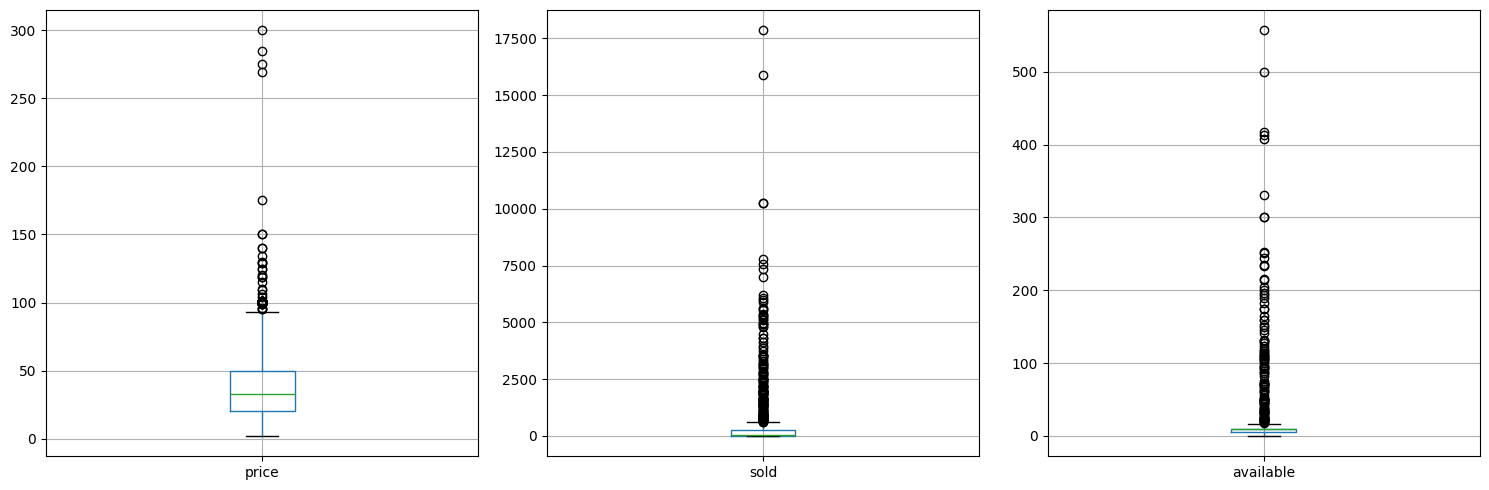

In [2561]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_clean_6.boxplot(column="price", ax=axes[0])
df_clean_6.boxplot(column="sold", ax=axes[1])
df_clean_6.boxplot(column="available", ax=axes[2])
plt.tight_layout()
plt.show()

### Deteksi Outlier - IQR

In [2562]:
Q1_price = df_clean_6['price'].quantile(0.25)
Q3_price = df_clean_6['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

outlier_iqr_price = df_clean_6[(df_clean_6['price'] < lower_price) | (df_clean_5['price'] > upper_price)]
outlier_iqr_price

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation
28,Ex Nihilo,Blue Taliman by Ex Nihilo Eau De Parfum 3.3oz/...,Eau de Parfum,99.99,4.0,4 available / 29 sold,29.0,"May 23, 2024 03:50:04","California or Hong Kong, Hong Kong"
34,Roja,Roja Parfums Isola Blu Parfum Unisex 50ml / 1....,Eau de Parfum,129.99,5.0,5 available / 37 sold,37.0,"May 24, 2024 09:25:04","United States, Canada"
46,Parfums De Marly,PARFUMS de MARLY DELINA for WOMEN 2.5 oz (75ml...,Eau de Parfum,100.99,1.0,last one / 49 sold,49.0,"May 17, 2024 03:05:11","Buffalo Mills, Pennsylvania, United States"
55,Yves Saint Laurent,"Libre, Eau De Parfum Intense By Yves Saint Lau...",Eau de Parfum,98.99,3.0,3 available / 56 sold,56.0,"Apr 24, 2024 01:25:42","Houston, Texas, United States"
112,Valentino,VALENTINO DONNA BORN IN ROMA INTENSE 3.4 oz 10...,Eau de Parfum,100.99,1.0,last one / 47 sold,47.0,"May 17, 2024 03:30:44","Buffalo Mills, Pennsylvania, United States"
116,Kilian,Good Girl Gone Bad by Kilian 1.7 oz / 50 ml Ea...,Eau de Parfum,100.99,1.0,last one / 48 sold,48.0,"May 17, 2024 03:24:34","Buffalo Mills, Pennsylvania, United States"
138,Byredo,Byredo Mojave Ghost Eau de Parfum EDP Spray 3....,Eau de Parfum,100.99,1.0,last one / 13 sold,13.0,"May 21, 2024 20:08:09","Oxnard, California, United States"
149,Lake&Skye,Lake & Skye 11 11 Eau De Parfum 3.4oz (WITHOU...,Eau de Parfum,99.99,2.0,2 available / 3 sold,3.0,"May 23, 2024 20:28:37","Elgin, Illinois, United States"
169,Carolina Herrera,Good Girl BLUSH by Carolina Herrera 2.7 oz.EDP...,Eau de Parfum,119.99,10.0,10 available / 141 sold,141.0,"May 20, 2024 06:18:08","Katy, Texas, United States"
175,Valentino,Valentino Donna Born In Roma Perfume 3.4oz.EDP...,Eau de Parfum,109.95,10.0,10 available / 416 sold,416.0,"May 24, 2024 08:56:33","Katy, Texas, United States"


In [2563]:
Q1_sold = df_clean_6['sold'].quantile(0.25)
Q3_sold = df_clean_6['sold'].quantile(0.75)
IQR_sold = Q3_sold - Q1_sold

lower_sold = Q1_sold - 1.5 * IQR_sold
upper_sold = Q3_sold + 1.5 * IQR_sold

outlier_iqr_sold = df_clean_6[(df_clean_6['sold'] < lower_sold) | (df_clean_5['sold'] > upper_sold)]
outlier_iqr_sold

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation
19,Dolce & Gabbana,D&G DOLCE & GABBANA LIGHT BLUE EAU INTENSE WOM...,Eau de Parfum,11.00,10.0,"more than 10 available / 1,613 sold",1613.0,"Apr 05, 2024 00:52:19","Albany, New York, United States"
29,Juliette Has A Gun,Not a Perfume by Juliette has a gun 3.3 oz EDP...,Eau de Parfum,40.92,10.0,"limited quantity available / 1,571 sold",1571.0,"May 24, 2024 07:32:36","Hackensack, New Jersey, United States"
61,Versace,Versace Bright Crystal Eau De Toilette Rollerb...,Eau de Toilette,15.49,10.0,"more than 10 available / 1,089 sold",1089.0,"Apr 30, 2024 06:41:19","Keyport, New Jersey, United States"
68,Juicy Couture,VIVA LA JUICY GOLD COUTURE by Juicy Couture Wo...,Eau de Parfum,36.79,68.0,"68 available / 1,498 sold",1498.0,"May 24, 2024 09:05:08","Dallas, Texas, United States"
69,Marc Jacobs,Daisy Eau So Fresh Perfume by Marc Jacobs 4.2 ...,Eau de Toilette,39.99,10.0,"more than 10 available / 1,129 sold",1129.0,"May 24, 2024 06:47:19","Lincoln Park, Michigan, United States"
...,...,...,...,...,...,...,...,...,...
925,Christian Audigier,Ed Hardy by Christian Audigier Perfume for Wom...,Eau de Parfum,22.90,10.0,"limited quantity available / 3,510 sold",3510.0,"May 24, 2024 10:58:03","Hackensack, New Jersey, United States"
934,Donna Karan,Donna Karan Cashmere Mist 3.4 oz / 100ml Women...,Eau de Parfum,29.95,8.0,"8 available / 1,239 sold",1239.0,"May 22, 2024 08:24:55","Warren, Michigan, United States"
949,Oscar De La Renta,OSCAR by Oscar de la Renta for women EDT 6.7 o...,Eau de Toilette,43.39,1.0,last one / 678 sold,678.0,"May 22, 2024 05:09:56","Dallas, Texas, United States"
973,Ariana Grande,Sweet Like Candy by Ariana Grande perfume 3.3 ...,Eau de Parfum,29.53,50.0,50 available / 856 sold,856.0,"May 24, 2024 10:56:09","Dallas, Texas, United States"


In [2564]:
Q1_avail = df_clean_6['available'].quantile(0.25)
Q3_avail = df_clean_6['available'].quantile(0.75)
IQR_avail = Q3_avail - Q1_avail

lower_avail = Q1_avail - 1.5 * IQR_avail
upper_avail = Q3_avail + 1.5 * IQR_avail

outlier_iqr_avail = df_clean_6[(df_clean_6['available'] < lower_avail) | (df_clean_5['available'] > upper_avail)]
outlier_iqr_avail

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation
22,Unknown,Lattafa YARA by Lattafa 3.4 Oz (100 ml) EDP Ea...,Eau de Parfum,16.27,300.0,300 available / 38 sold,38.0,"May 24, 2024 08:20:15","shanghai, China"
39,Versace,Versace Dylan Turquoise by Gianni Versace for ...,Eau de Toilette,32.20,60.0,60 available / 157 sold,157.0,"May 17, 2024 06:09:15","Dallas, Texas, United States"
68,Juicy Couture,VIVA LA JUICY GOLD COUTURE by Juicy Couture Wo...,Eau de Parfum,36.79,68.0,"68 available / 1,498 sold",1498.0,"May 24, 2024 09:05:08","Dallas, Texas, United States"
74,Elizabeth Arden,Elizabeth Arden White Tea Fragrance Collection...,Gift Set,19.45,50.0,50 available / 2 sold,2.0,"May 24, 2024 07:12:19","Ronkonkoma, New York, United States"
85,Kim Kardashian,KIM KARDASHIAN GOLD Perfume 3.3 / 3.4 oz EDP F...,Eau de Parfum,16.63,37.0,37 available / 528 sold,528.0,"May 14, 2024 12:55:23","Dallas, Texas, United States"
...,...,...,...,...,...,...,...,...,...
970,Versace,VERSACE EROS POUR FEMME 3.4 oz 3.3 edt Perfume...,Eau de Toilette,44.95,107.0,107 available / 32 sold,32.0,"May 23, 2024 08:46:36","Dallas, Texas, United States"
973,Ariana Grande,Sweet Like Candy by Ariana Grande perfume 3.3 ...,Eau de Parfum,29.53,50.0,50 available / 856 sold,856.0,"May 24, 2024 10:56:09","Dallas, Texas, United States"
988,Ralph Lauren,RALPH by Ralph Lauren 3.3 / 3.4 oz EDT For Wom...,Eau de Toilette,47.69,41.0,41 available / 269 sold,269.0,"May 22, 2024 23:11:31","Dallas, Texas, United States"
989,Dkny,Be Extra Delicious By DKNY 0.24oz EDP Women's ...,Eau de Parfum,14.95,19.0,19 available / 5 sold,5.0,"May 08, 2024 16:32:50","Fort Lauderdale, Florida, United States"


In [2565]:
jml_outlier_price = len(outlier_iqr_price)
total_outlier_price = len(df_clean_6)
persen_outlier_price = (jml_outlier_price / total_outlier_price) * 100
print(f"Persentase outlier pada kolom price: {persen_outlier_price:.2f}%")

jml_outlier_sold = len(outlier_iqr_sold)
total_outlier_sold = len(df_clean_6)
persen_outlier_sold = (jml_outlier_sold / total_outlier_sold) * 100
print(f"Persentase outlier pada kolom sold: {persen_outlier_sold:.2f}%")

jml_outlier_avail = len(outlier_iqr_avail)
total_outlier_avail = len(df_clean_6)
persen_outlier_avail = (jml_outlier_avail / total_outlier_avail) * 100
print(f"Persentase outlier pada kolom available: {persen_outlier_avail:.2f}%")

Persentase outlier pada kolom price: 5.21%
Persentase outlier pada kolom sold: 14.81%
Persentase outlier pada kolom available: 11.71%


### Outlier Handling dengan Log Transform

In [2566]:
# outlier handling dengan transformasi log
df_clean_6['sold_log'] = np.log1p(df_clean_6['sold'])

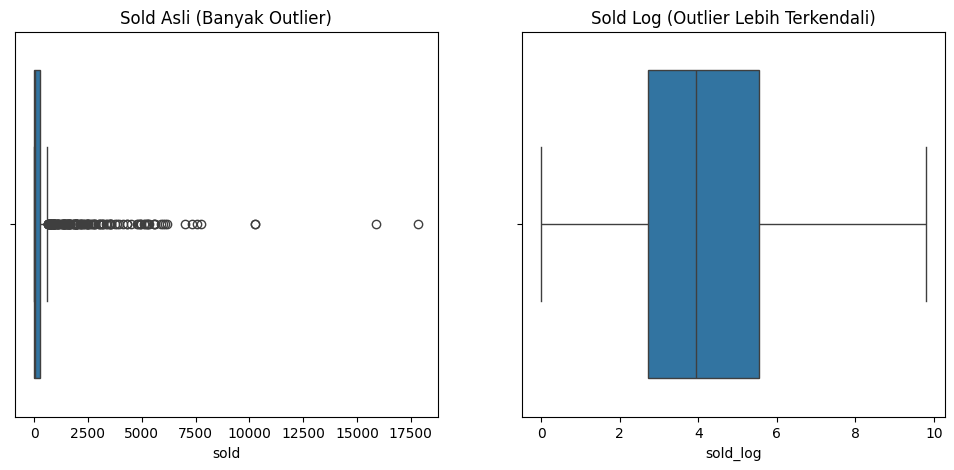

In [2567]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot sebelum Log
sns.boxplot(x=df_clean_6['sold'], ax=axes[0])
axes[0].set_title("Sold Asli (Banyak Outlier)")

# Boxplot sesudah Log
sns.boxplot(x=df_clean_6['sold_log'], ax=axes[1])
axes[1].set_title("Sold Log (Outlier Lebih Terkendali)")

plt.show()

In [2568]:
# outlier handling dengan transformasi log
df_clean_6['available_log'] = np.log1p(df_clean_6['available'])

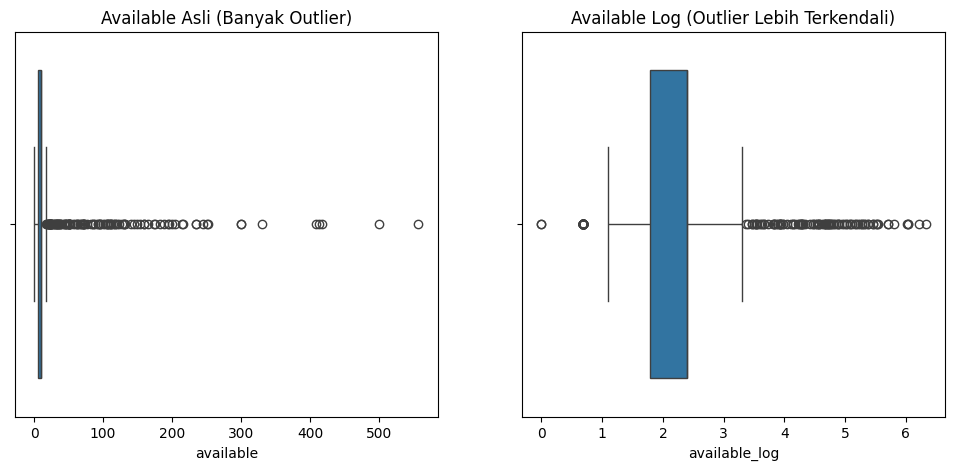

In [2569]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot sebelum Log
sns.boxplot(x=df_clean_6['available'], ax=axes[0])
axes[0].set_title("Available Asli (Banyak Outlier)")

# Boxplot sesudah Log
sns.boxplot(x=df_clean_6['available_log'], ax=axes[1])
axes[1].set_title("Available Log (Outlier Lebih Terkendali)")

plt.show()

### Memeriksa normalitas data

In [2570]:
from scipy.stats import shapiro

# List kolom yang ingin dicek
kolom_numerik = ['price', 'sold', 'available']

for col in kolom_numerik:
    # Menghapus NaN jika ada agar tidak error
    data = df_clean_6[col].dropna()
    
    stat, p = shapiro(data)
    
    print(f"=== Uji Normalitas Kolom: {col} ===")
    print(f"Statistik Uji: {stat:.4f}")
    print(f"P-Value      : {p:.10f}")
    
    if p > 0.05:
        print("Hasil        : Data berdistribusi Normal")
    else:
        print("Hasil        : Data TIDAK berdistribusi Normal")
    print("-" * 40)


=== Uji Normalitas Kolom: price ===
Statistik Uji: 0.7672
P-Value      : 0.0000000000
Hasil        : Data TIDAK berdistribusi Normal
----------------------------------------
=== Uji Normalitas Kolom: sold ===
Statistik Uji: 0.3818
P-Value      : 0.0000000000
Hasil        : Data TIDAK berdistribusi Normal
----------------------------------------
=== Uji Normalitas Kolom: available ===
Statistik Uji: 0.3261
P-Value      : 0.0000000000
Hasil        : Data TIDAK berdistribusi Normal
----------------------------------------


#### Pengujian untuk Normalisasi Data

Metode Original     | P-Value: 0.0000000000
Metode Square Root  | P-Value: 0.0000000000
Metode Log          | P-Value: 0.0400681177
Metode Box-Cox      | P-Value: 0.0539845273


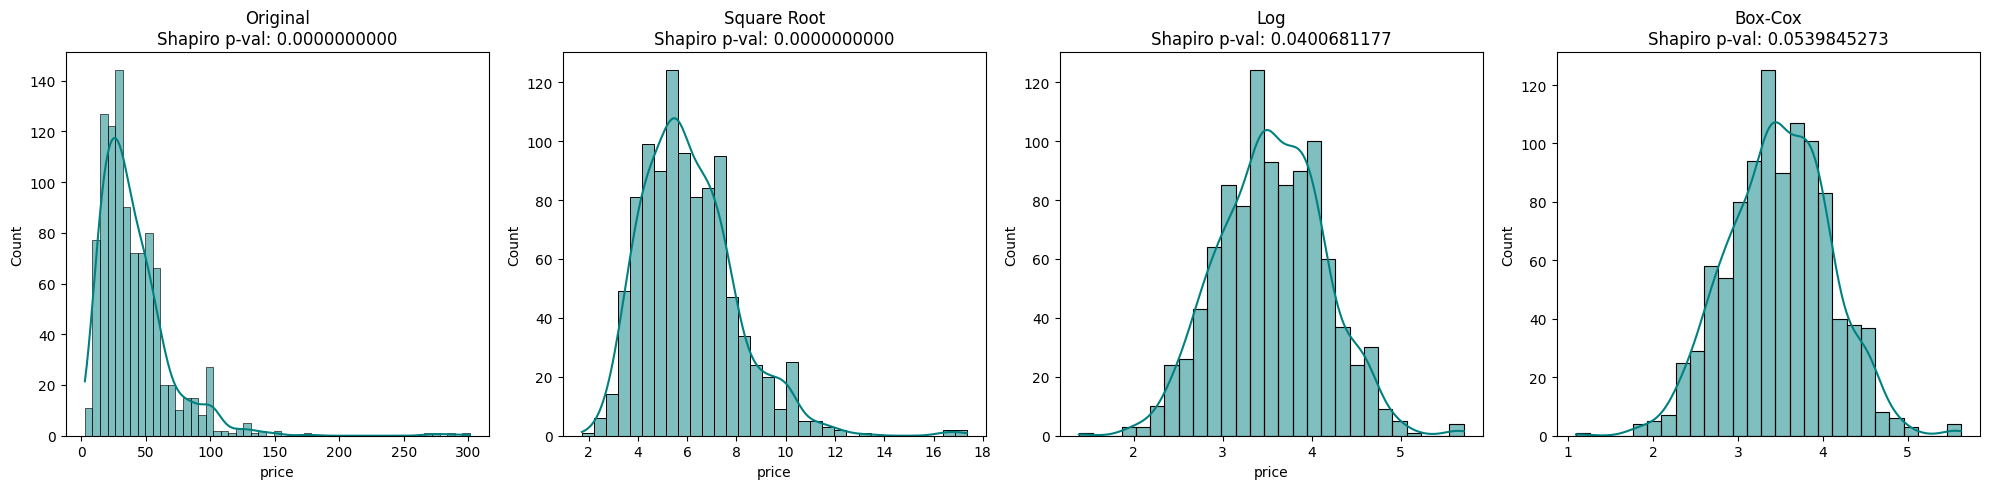

Metode Original     | P-Value: 0.0000000000
Metode Square Root  | P-Value: 0.0000000000
Metode Log          | P-Value: 0.0000000000
Metode Box-Cox      | P-Value: 0.0000052717


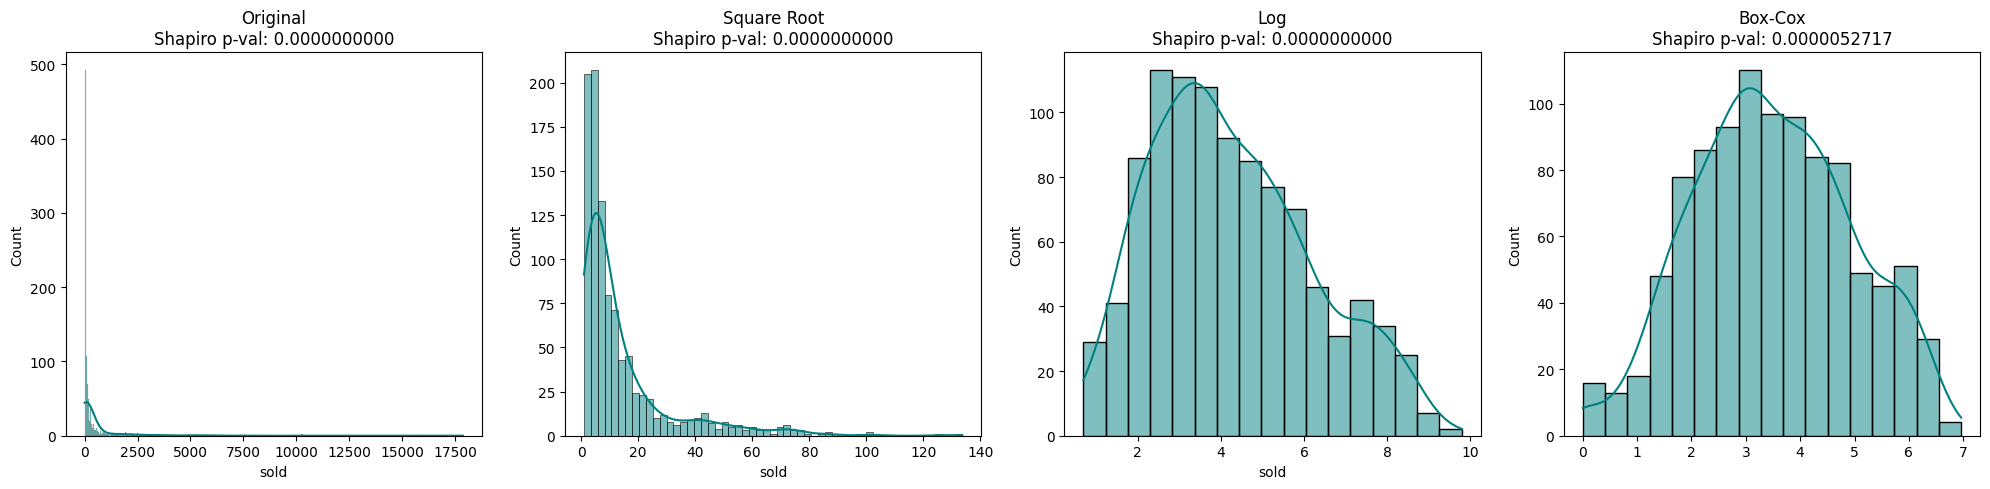

Metode Original     | P-Value: 0.0000000000
Metode Square Root  | P-Value: 0.0000000000
Metode Log          | P-Value: 0.0000000000
Metode Box-Cox      | P-Value: 0.0000000000


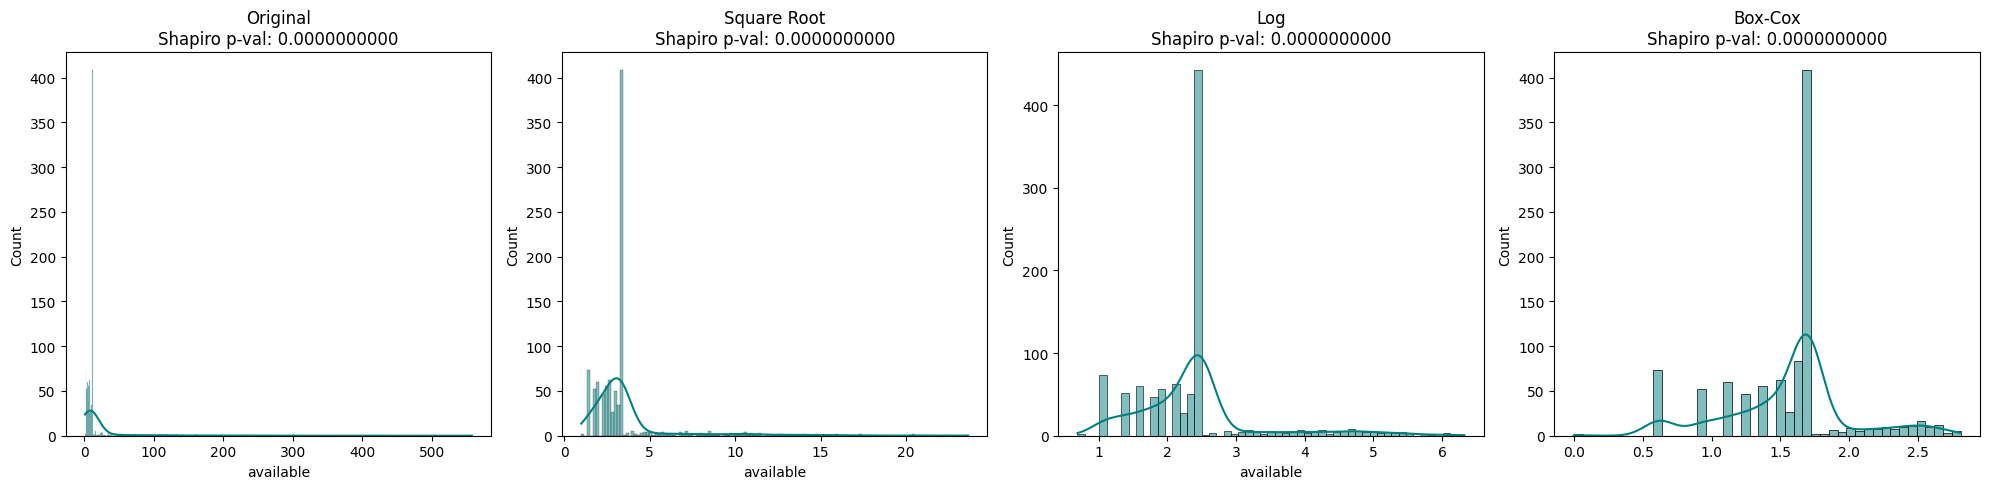

In [2571]:
def try_transformations(df, column):
    
    # (tambah 1 untuk menghindari log(0) atau boxcox(0))
    data_asli = df[column] + 1
    
    # METODE 1: SQUARE ROOT
    data_sqrt = np.sqrt(data_asli)
    
    # METODE 2: LOG TRANSFORMATION
    data_log = np.log1p(data_asli)
    
    # METODE 3: BOX-COX
    data_boxcox, lam = stats.boxcox(data_asli)
    
    # List untuk looping visualisasi
    methods = [
        ('Original', data_asli),
        ('Square Root', data_sqrt),
        ('Log', data_log),
        ('Box-Cox', data_boxcox)
    ]
    
    # Visualisasi Perbandingan
    plt.figure(figsize=(20, 5))
    for i, (name, data) in enumerate(methods):
        plt.subplot(1, 4, i+1)
        sns.histplot(data, kde=True, color='teal')
        
        # Hitung Shapiro-Wilk
        stat, p = stats.shapiro(data)
        plt.title(f"{name}\nShapiro p-val: {p:.10f}")
        
        print(f"Metode {name:12} | P-Value: {p:.10f}")
    
    plt.tight_layout()
    plt.show()

kolom_numerik = ['price', 'sold', 'available']

for col in kolom_numerik:
    try_transformations(df_clean_6, col)

In [2572]:
# simpan hasil price boxcox ke kolom baru
df_clean_6['price_boxcox'], _ = stats.boxcox(df_clean_6['price'] + 1)

In [2573]:
df_clean_6.head(5)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2.0,2 available / 393 sold,393.0,"May 23, 2024 10:43:50","Thomasville, Alabama, United States",5.976351,1.098612,3.770667
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5.0,5 available / 40 sold,40.0,"May 24, 2024 00:15:48","New Jersey, Hong Kong",3.713572,1.791759,4.346696
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10.0,more than 10 available / 35 sold,35.0,"May 14, 2024 20:54:25","Orange, New Jersey, United States",3.583519,2.397895,4.069010
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,10.0,more than 10 available / 9 sold,9.0,"May 23, 2024 01:23:05","USA, New Jersey, Hong Kong",2.302585,2.397895,4.069010
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10.0,more than 10 available,0.0,"May 08, 2024 16:32:50","Little Ferry, New Jersey, United States",0.000000,2.397895,3.404537


In [2574]:
df_clean_6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          999 non-null    object 
 1   title          999 non-null    object 
 2   type           999 non-null    object 
 3   price          999 non-null    float64
 4   available      999 non-null    float64
 5   availableText  991 non-null    object 
 6   sold           999 non-null    float64
 7   lastUpdated    999 non-null    object 
 8   itemLocation   999 non-null    object 
 9   sold_log       999 non-null    float64
 10  available_log  999 non-null    float64
 11  price_boxcox   999 non-null    float64
dtypes: float64(6), object(6)
memory usage: 133.8+ KB


In [2575]:
# memeriksa nunique title
df_clean_6['title'].str.strip().str.lower()
df_clean_6['title'].nunique()

975

## 4. Data Manipulation

In [2576]:
df_manip = df_clean_6.copy()

### Type Conversion

In [2577]:
df_manip['sold'] = df_manip['sold'].round().astype(int)
df_manip['available'] = df_manip['available'].round().astype(int)
df_manip['lastUpdated'] = pd.to_datetime(df_manip['lastUpdated'], errors='coerce', format='mixed')

In [2578]:
df_manip.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   brand          999 non-null    object        
 1   title          999 non-null    object        
 2   type           999 non-null    object        
 3   price          999 non-null    float64       
 4   available      999 non-null    int64         
 5   availableText  991 non-null    object        
 6   sold           999 non-null    int64         
 7   lastUpdated    999 non-null    datetime64[ns]
 8   itemLocation   999 non-null    object        
 9   sold_log       999 non-null    float64       
 10  available_log  999 non-null    float64       
 11  price_boxcox   999 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 133.8+ KB


In [2579]:
df_manip.head(5)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,2 available / 393 sold,393,2024-05-23 10:43:50,"Thomasville, Alabama, United States",5.976351,1.098612,3.770667
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,5 available / 40 sold,40,2024-05-24 00:15:48,"New Jersey, Hong Kong",3.713572,1.791759,4.346696
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,more than 10 available / 35 sold,35,2024-05-14 20:54:25,"Orange, New Jersey, United States",3.583519,2.397895,4.069010
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,10,more than 10 available / 9 sold,9,2024-05-23 01:23:05,"USA, New Jersey, Hong Kong",2.302585,2.397895,4.069010
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10,more than 10 available,0,2024-05-08 16:32:50,"Little Ferry, New Jersey, United States",0.000000,2.397895,3.404537


### Esktrak Hari dan Bulan

In [2580]:
# Ekstrak Hari dan bulan
df_manip['update_month'] = df_manip['lastUpdated'].dt.month
df_manip['update_day'] = df_manip['lastUpdated'].dt.day

df_manip.head(5)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox,update_month,update_day
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,2 available / 393 sold,393,2024-05-23 10:43:50,"Thomasville, Alabama, United States",5.976351,1.098612,3.770667,5,23
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,5 available / 40 sold,40,2024-05-24 00:15:48,"New Jersey, Hong Kong",3.713572,1.791759,4.346696,5,24
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,more than 10 available / 35 sold,35,2024-05-14 20:54:25,"Orange, New Jersey, United States",3.583519,2.397895,4.069010,5,14
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,10,more than 10 available / 9 sold,9,2024-05-23 01:23:05,"USA, New Jersey, Hong Kong",2.302585,2.397895,4.069010,5,23
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10,more than 10 available,0,2024-05-08 16:32:50,"Little Ferry, New Jersey, United States",0.000000,2.397895,3.404537,5,8


### Tambah Kolom Revenue

In [2581]:
df_manip['revenue'] = df_manip['price'] * df_manip['sold']
df_manip.head(5)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox,update_month,update_day,revenue
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,2 available / 393 sold,393,2024-05-23 10:43:50,"Thomasville, Alabama, United States",5.976351,1.098612,3.770667,5,23,17288.07
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,5 available / 40 sold,40,2024-05-24 00:15:48,"New Jersey, Hong Kong",3.713572,1.791759,4.346696,5,24,3199.60
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,more than 10 available / 35 sold,35,2024-05-14 20:54:25,"Orange, New Jersey, United States",3.583519,2.397895,4.069010,5,14,2099.65
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,10,more than 10 available / 9 sold,9,2024-05-23 01:23:05,"USA, New Jersey, Hong Kong",2.302585,2.397895,4.069010,5,23,539.91
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10,more than 10 available,0,2024-05-08 16:32:50,"Little Ferry, New Jersey, United States",0.000000,2.397895,3.404537,5,8,0.00


### Ekstrak lokasi item

In [2582]:
# Ekstrak Negara (kata terakhir setelah koma terakhir)
df_manip['country'] = df_manip['itemLocation'].str.split(',').str[-1].str.strip()

# Ekstrak State/Provinsi (kata kedua dari belakang)
# Jika hanya ada 1 bagian, kita isi dengan 'Unknown'
def get_state(x):
    parts = str(x).split(',')
    return parts[-2].strip() if len(parts) > 1 else 'Unknown'

df_manip['state'] = df_manip['itemLocation'].apply(get_state)

df_manip.head(3)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox,update_month,update_day,revenue,country,state
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,2 available / 393 sold,393,2024-05-23 10:43:50,"Thomasville, Alabama, United States",5.976351,1.098612,3.770667,5,23,17288.07,United States,Alabama
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,5 available / 40 sold,40,2024-05-24 00:15:48,"New Jersey, Hong Kong",3.713572,1.791759,4.346696,5,24,3199.60,Hong Kong,New Jersey
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,more than 10 available / 35 sold,35,2024-05-14 20:54:25,"Orange, New Jersey, United States",3.583519,2.397895,4.069010,5,14,2099.65,United States,New Jersey


In [2583]:
df_manip['country'].value_counts()

C:\Users\Irvan N\AppData\Roaming\Python\Python312\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


country
United States     921
Hong Kong          48
China              14
Taiwan              6
Canada              5
Japan               1
Estados Unidos      1
India               1
Pakistan            1
Bulgaria            1
Name: count, dtype: int64

### Groupby & Agregasi

In [2584]:
# Menghitung rata-rata penjualan
mean_sold = df_manip['sold'].median()

# Filter: Produk dengan penjualan > rata-rata DAN stok masih tersedia (> 0)
hero_products = df_manip[(df_manip['sold'] > mean_sold) & (df_manip['available'] > 0)]

# Menampilkan hasil (hanya kolom tertentu agar rapi)
hero_products[['brand', 'title', 'price', 'sold', 'available']].head()

,brand,title,price,sold,available
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,43.99,393,2
5,Viktor & Rolf,Flowerbomb by Viktor & Rolf 3.4 oz 100ML Eau D...,51.99,184,8
7,Versace,Versace Bright Crystal Women EDT 6.7 oz 200 ml...,52.79,258,6
8,Versace,Versace Bright Crystal by Versace for Women ED...,29.99,251,1
9,Lattafa,Fakhar by Lattafa Eau de Parfum 3.4 oz / 100 m...,22.75,174,10


In [2585]:
# Analisis Kombinasi Tipe dan Brand yang Paling Laku
top_combinations = df_manip.groupby(['type', 'brand']).agg(
    total_sold=('sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    median_price=('price', 'median')
).sort_values(by='total_sold', ascending=False)

# Menampilkan 10 kombinasi teratas
print(top_combinations.head(10))

                                       total_sold  total_revenue  median_price
type            brand                                                         
Eau de Parfum   Calvin Klein                43892     1180147.08        25.560
Eau de Toilette Versace                     22306      510487.61        35.315
Eau de Parfum   Vera Wang                   15897      401399.25        25.250
                Juicy Couture               14054      435862.15        29.115
Eau de Toilette Elizabeth Taylor            13693      259257.52        18.060
Eau de Parfum   Versace                     11956      532531.85        54.705
Eau de Toilette Dolce & Gabbana             11873      516791.14        31.720
                Giorgio Beverly Hills       11092      194570.35        18.965
                Gloria Vanderbilt           10268      131225.04        12.780
Eau de Parfum   Christian Audigier          10031      213028.50        20.420


In [2586]:
# berapa total revenue dan median penjualan per brand
brand_analysis = df_manip.groupby('brand').agg(
    revenue=('revenue','sum'),
    sold=('sold','median'),
    price=('price','median')
).sort_values(by='revenue', ascending=False)

brand_analysis

,revenue,sold,price
brand,,,
Calvin Klein,1274841.86,615.0,25.56
Versace,1045867.36,157.0,38.76
Dolce & Gabbana,853365.20,120.0,32.49
Burberry,652690.69,95.0,34.51
Vera Wang,511833.43,4123.0,25.25
...,...,...,...
Love Luxe Beauty,15.00,1.0,15.00
Giardini Di Toscana,0.00,0.0,140.00
Jean Couturier,0.00,0.0,21.95


In [2587]:
# berapa stok yang terjual dan harga nya
brand_sold = df_manip.groupby('brand').agg(
    sold=('sold','median'),
    price=('price','median')
).sort_values(by='sold',ascending=False)

brand_sold

,sold,price
brand,,
Gloria Vanderbilt,10268.0,12.780
Coty,7331.0,14.890
Guess,5628.0,20.670
Giorgio Beverly Hills,5546.0,18.965
Perfumer'S Workshop,4492.0,13.760
...,...,...
Ellis Brooklyn,0.0,17.000
Giardini Di Toscana,0.0,140.000
Jean Couturier,0.0,21.950


In [2588]:
# analisa lokasi item/penjual
country_analysis = df_manip.groupby('country').agg(
    avg_price=('price', 'median'),
    total_sold=('sold', 'sum'),
    total_listing=('brand', 'count')
).sort_values(by='total_listing', ascending=False)

country_analysis

,avg_price,total_sold,total_listing
country,,,
United States,30.99,486350,921
Hong Kong,59.99,1638,48
China,32.42,657,14
Taiwan,51.99,230,6
Canada,55.99,238,5
Bulgaria,29.66,163,1
India,139.99,43,1
Estados Unidos,29.99,0,1
Pakistan,29.60,20,1


In [2589]:
# melihat jenis parfum mana yang paling dicari pembeli ebay
type_analysis = df_manip.groupby('type').agg(
    median_price=('price', 'median'),
    total_sold=('sold', 'sum'),
    total_revenue=('revenue', 'sum')
).sort_values(by='total_revenue', ascending=False)

type_analysis

,median_price,total_sold,total_revenue
type,,,
Eau de Parfum,33.995,286436,8636628.81
Eau de Toilette,29.990,176339,4771153.87
Cologne,49.990,20851,319279.05
Body Care,26.990,4492,86215.35
Extrait de Parfum,53.750,710,37047.86
Gift Set,17.990,294,32673.90
Body Mist,22.000,150,3731.64
Others,29.990,61,1035.00
Perfume Spray,9.250,30,277.50


In [2590]:
# melakukan Scaling (Min-Max) agar memaksa semua nilai masuk ke rentang 0 sampai 1
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

robust = RobustScaler()
std_scaler = StandardScaler()

df_manip['price_scaled'] = std_scaler.fit_transform(df_manip[['price_boxcox']])

df_manip['sold_robust'] = robust.fit_transform(df_manip[['sold']])
df_manip['available_robust'] = robust.fit_transform(df_manip[['available']])

df_manip.head(5)

,brand,title,type,price,available,availableText,sold,lastUpdated,itemLocation,sold_log,available_log,price_boxcox,update_month,update_day,revenue,country,state,price_scaled,sold_robust,available_robust
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,2 available / 393 sold,393,2024-05-23 10:43:50,"Thomasville, Alabama, United States",5.976351,1.098612,3.770667,5,23,17288.07,United States,Alabama,0.467689,1.407407,-1.6
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,5 available / 40 sold,40,2024-05-24 00:15:48,"New Jersey, Hong Kong",3.713572,1.791759,4.346696,5,24,3199.60,Hong Kong,New Jersey,1.419105,-0.045267,-1.0
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,more than 10 available / 35 sold,35,2024-05-14 20:54:25,"Orange, New Jersey, United States",3.583519,2.397895,4.069010,5,14,2099.65,United States,New Jersey,0.960457,-0.065844,0.0
3,Unknown,J'adore Parfum D'eau by Christian 3.4 oz EDP F...,Eau de Parfum,59.99,10,more than 10 available / 9 sold,9,2024-05-23 01:23:05,"USA, New Jersey, Hong Kong",2.302585,2.397895,4.069010,5,23,539.91,Hong Kong,New Jersey,0.960457,-0.172840,0.0
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,10,more than 10 available,0,2024-05-08 16:32:50,"Little Ferry, New Jersey, United States",0.000000,2.397895,3.404537,5,8,0.00,United States,New Jersey,-0.137041,-0.209877,0.0


In [2591]:
# Membuang kolom yang tidak terpakai

columns_to_drop = ['lastUpdated', 'itemLocation', 'availableText', 'sold_log', 'available_log']
df_manip.drop(columns=columns_to_drop, inplace=True)

df_manip.head(3)

,brand,title,type,price,available,sold,price_boxcox,update_month,update_day,revenue,country,state,price_scaled,sold_robust,available_robust
0,Carolina Herrera,Good Girl by Carolina Herrera 2.7 oz Eau De Pa...,Eau de Parfum,43.99,2,393,3.770667,5,23,17288.07,United States,Alabama,0.467689,1.407407,-1.6
1,Unknown,Parfums de Marly Delina La Rosee Eau de Parfum...,Eau de Parfum,79.99,5,40,4.346696,5,24,3199.60,Hong Kong,New Jersey,1.419105,-0.045267,-1.0
2,Prada,PRADA Paradoxe by Prada EDP 3.0oz/90ml Spray P...,Eau de Parfum,59.99,10,35,4.069010,5,14,2099.65,United States,New Jersey,0.960457,-0.065844,0.0


#### Encoding Kolom Kategorikal

In [2592]:
df_encoded = df_manip.copy()

In [2593]:
import category_encoders as ce

# 1. One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=['type', 'country'], prefix=['type', 'country'])

# 2. Binary Encoding untuk Brand dan State
be = ce.BinaryEncoder(cols=['brand', 'state'])
df_encoded = be.fit_transform(df_encoded)

# 3. Hashing Encoding untuk Title
he = ce.HashingEncoder(cols=['title'], n_components=16)
df_encoded = he.fit_transform(df_encoded)

In [2594]:
df_encoded.head(3)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,country_Bulgaria,country_Canada,country_China,country_Estados Unidos,country_Hong Kong,country_India,country_Japan,country_Pakistan,country_Taiwan,country_United States
0,0,0,0,0,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
1,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True


## 5. Output Final

In [2595]:
# dataframe akhir hasil encoding
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   col_0                   999 non-null    int64  
 1   col_1                   999 non-null    int64  
 2   col_2                   999 non-null    int64  
 3   col_3                   999 non-null    int64  
 4   col_4                   999 non-null    int64  
 5   col_5                   999 non-null    int64  
 6   col_6                   999 non-null    int64  
 7   col_7                   999 non-null    int64  
 8   col_8                   999 non-null    int64  
 9   col_9                   999 non-null    int64  
 10  col_10                  999 non-null    int64  
 11  col_11                  999 non-null    int64  
 12  col_12                  999 non-null    int64  
 13  col_13                  999 non-null    int64  
 14  col_14                  999 non-null    int64  